# ttt_smooth_column

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
The CIAO setup for this window has changed from
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3
To:
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


---


In [2]:
/bin/rm -rf 14382
download_chandra_obsid 14382 mtl
mv -fv 14382/secondary/*fits.gz .
gunzip -f *fits.gz
rmdir -p 14382/secondary


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  mtl      fits      412 Kb  ####################          < 1 s  30347.0 kb/s

`14382/secondary/acisf14382_000N001_mtl1.fits.gz' -> `./acisf14382_000N001_mtl1.fits.gz'


In [3]:
dmtcalc acisf14382_000N001_mtl1.fits"[cols time,fp_temp]" \
    fptemp.fits exp="time=time-tstart"  clob+

## Plot raw data


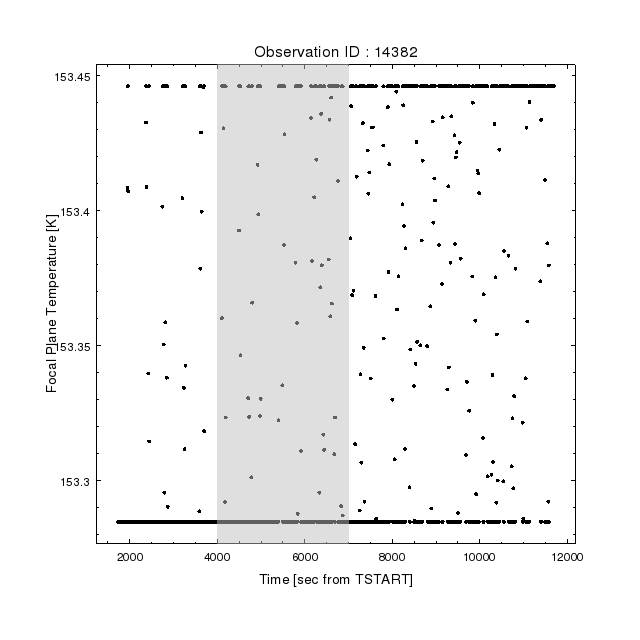

In [4]:
cat << EOM > c1.py
add_curve( "fptemp.fits[cols time,fp_temp]")
set_plot_xlabel("Time [sec from TSTART]" )
set_plot_ylabel("Focal Plane Temperature [K]") 
set_plot_title("Observation ID : 14382" )
set_curve("symbol.style=circle symbol.size=2 line.style=none")
add_region( [4000, 7000, 7000, 4000], [150, 150, 155, 155] )
set_region("fill.color=gray edge.style=none")
print_window("chips_01.png","export.clobber=True")
quit()
EOM

chips -n c1.py
display < chips_01.png


In [5]:
# A little helper to make plotting easier for this notebook

PlotFile()
{
infile="$1"
outfile="$2"

cat << EOM > ${outfile}.py
add_curve( "${infile}")
set_plot_xlabel("Time [sec from TSTART]" )
set_plot_ylabel("Focal Plane Temperature [K]") 
set_plot_title("Observation ID : 14382" )
set_curve("symbol.style=circle symbol.size=2 line.style=dot")
#add_region( [4000, 7000, 7000, 4000], [150, 150, 155, 155] )
#set_region("fill.color=gray edge.style=none")
#limits(X_AXIS, 4000, 7000)
print_window("$outfile","export.clobber=True")
quit()
EOM

chips -n ${outfile}.py
display < $outfile

}

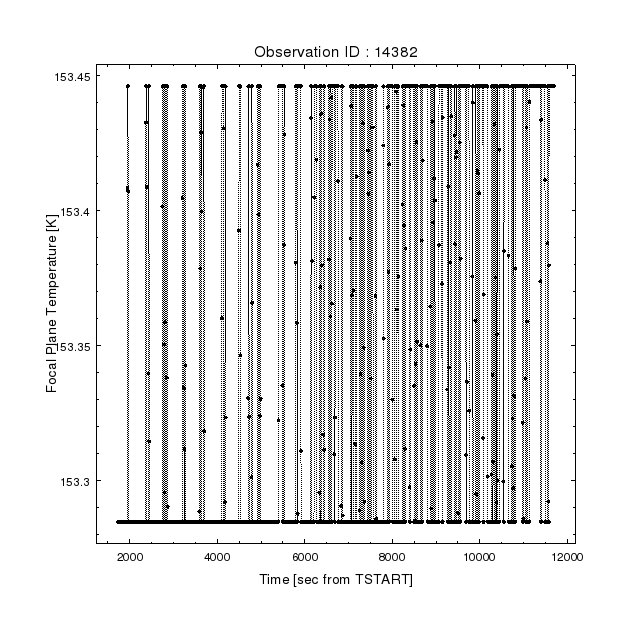

In [6]:
PlotFile "fptemp.fits[cols time,fp_temp]" chips_02.png

## Linear Smoothing

### Box

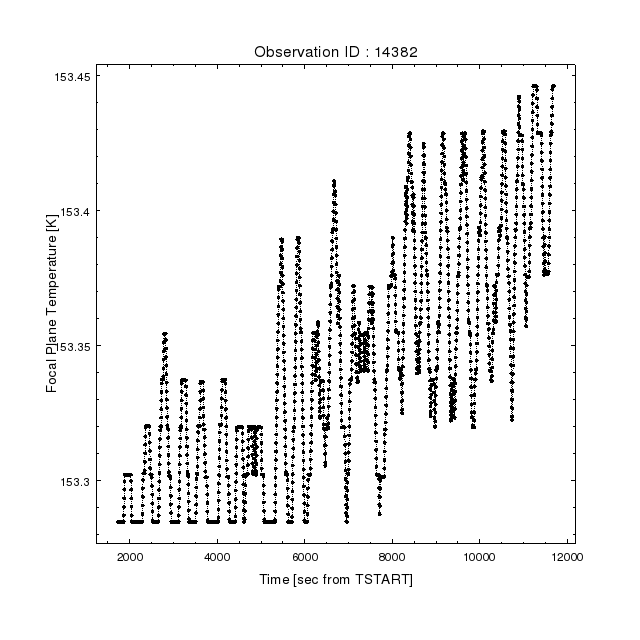

In [7]:
pset aconvolve infile="fptemp.fits[cols time,fp_temp]" 
pset aconvolve outfile=mean_fptemp.fits 
pset aconvolve kernelspec="lib:box(1,1,51)"  
pset aconvolve meth=slide edge=nearest norm=area clob+
aconvolve mode=h 

PlotFile "mean_fptemp.fits" chips03.png

### Gaus

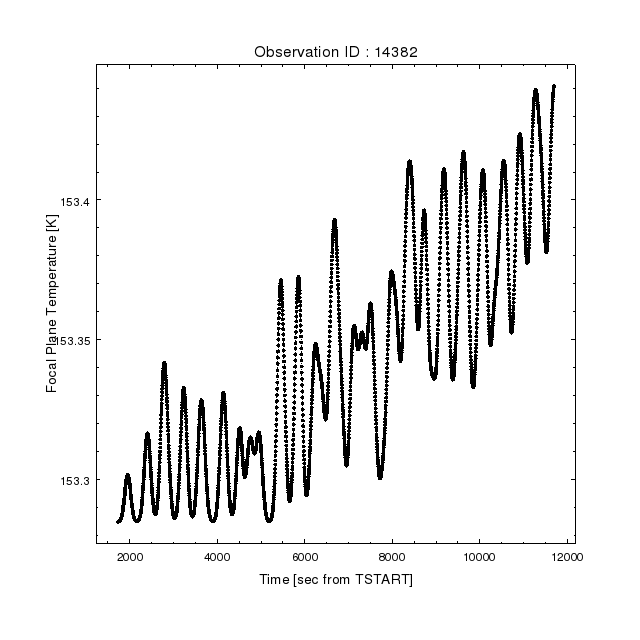

In [8]:
aconvolve fptemp.fits"[cols time,fp_temp]" gaus21_fptemp.fits \
  kernelspec="lib:gaus(1,5,1,21)" meth=slide edge=nearest clob+

PlotFile gaus21_fptemp.fits chips_04.png

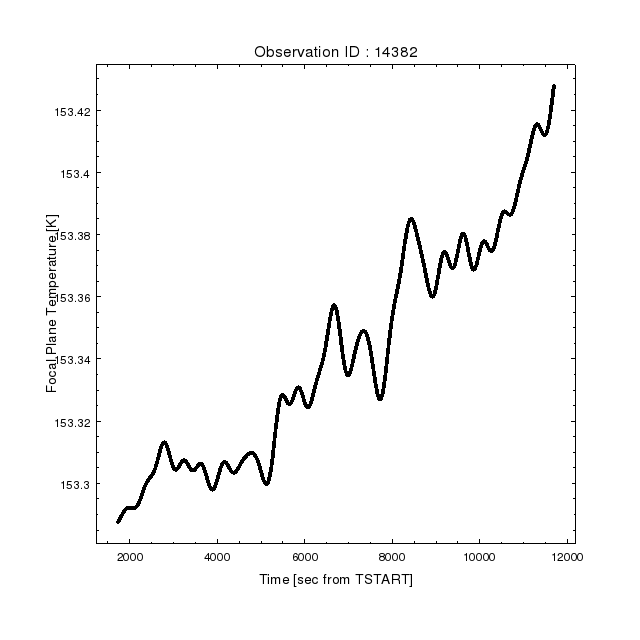

In [9]:
aconvolve fptemp.fits"[cols time,fp_temp]" gaus51_fptemp.fits \
  kernelspec="lib:gaus(1,5,1,51)" meth=slide edge=nearest clob+

PlotFile gaus51_fptemp.fits chips_06.png

## Non Linear Filters

In [10]:
pset dmtabfilt dmtabfilt infile=fptemp.fits 
pset dmtabfilt out=temp_out
pset dmtabfilt col=fp_temp 
pset dmtabfilt function=olympic 
pset dmtabfilt mask=")101"
dmtabfilt mode=h clob+

In [11]:
dmlist temp_out cols

 
--------------------------------------------------------------------------------
Columns for Table Block temp_out
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range
   1   fp_temp_olympic                   Real8          -Inf:+Inf            Smoothed version of column


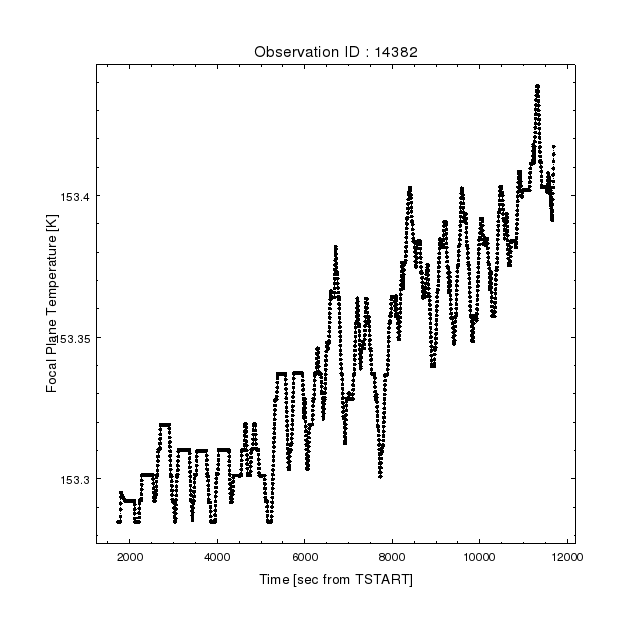

In [12]:
dmpaste fptemp.fits temp_out fp_temp_olympic101 clob+

PlotFile fp_temp_olympic101"[cols time,fp_temp_olympic]" chips_07.png 

# dmtabfilt (CIAO 4.9): WARNING: masks are typically odd length


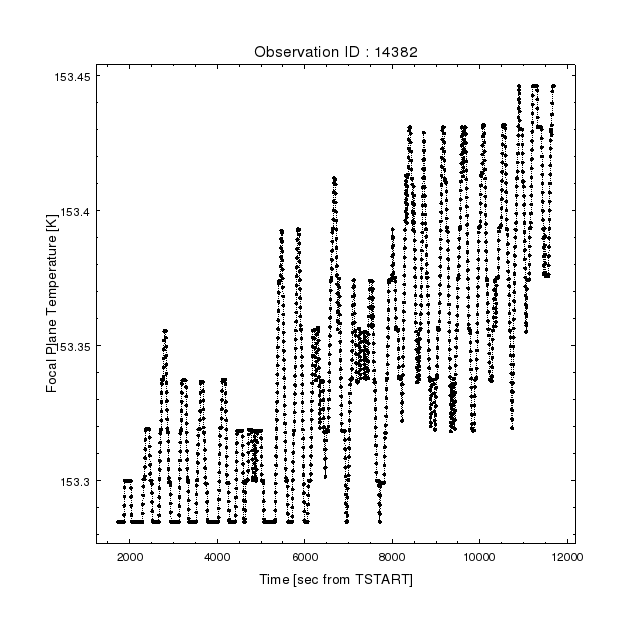

In [13]:
pset dmtabfilt dmtabfilt infile=fptemp.fits 
pset dmtabfilt out=temp_out
pset dmtabfilt col=fp_temp 
pset dmtabfilt function=olympic 
pset dmtabfilt mask="11111111111111111111111111111111111111111111111111"
dmtabfilt mode=h clob+
dmpaste fptemp.fits temp_out fp_temp_olympic51 clob+

PlotFile fp_temp_olympic51"[cols time,fp_temp_olympic]" chips_08.png 

### Quantiles

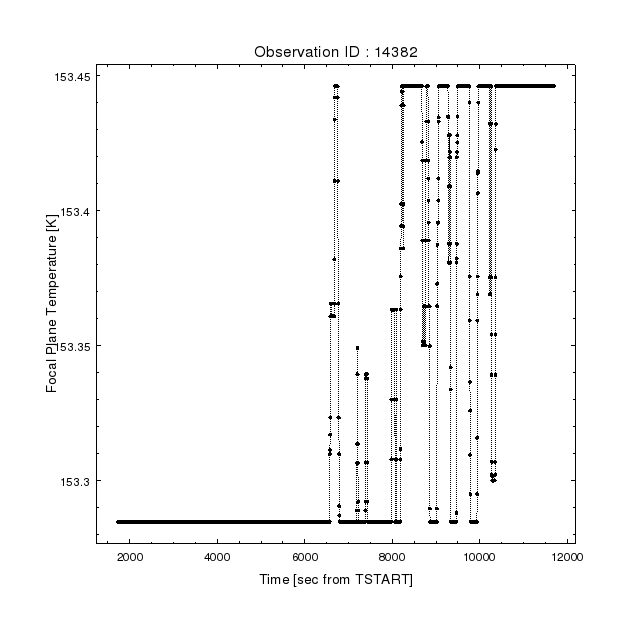

In [14]:
pset dmtabfilt infile=fptemp.fits 
pset dmtabfilt outfile=temp_out
pset dmtabfilt colname=fp_temp 
pset dmtabfilt function=median 
pset dmtabfilt mask=")101"
dmtabfilt mode=h clob+
dmpaste fptemp.fits temp_out fp_temp_median101 clob+

PlotFile fp_temp_median101"[cols time,fp_temp_median]" chips_09.png

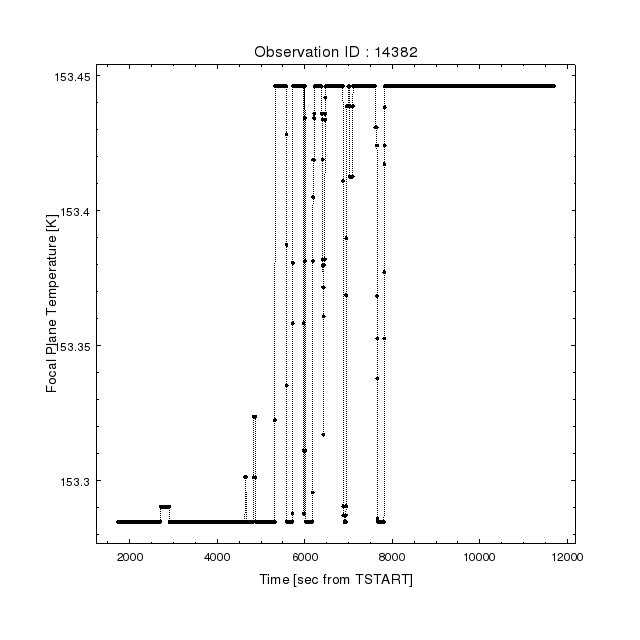

In [15]:
dmtabfilt in=fptemp.fits out=- col=fp_temp function=q75 mask=")101" | \
  dmpaste fptemp.fits - fp_temp_q75101 clob+

PlotFile fp_temp_q75101"[cols time,fp_temp_q75]" chips_10.png

### Extreme

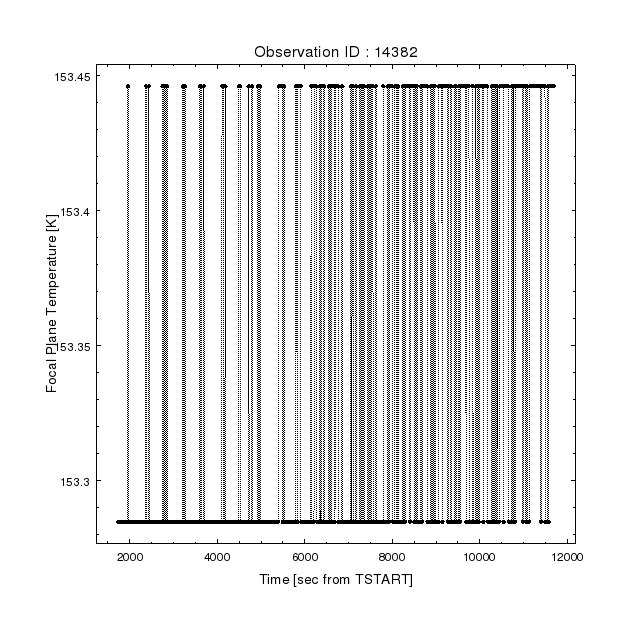

In [16]:
dmtabfilt in=fptemp.fits out=- col=fp_temp function=extreme mask="111" | \
  dmpaste fptemp.fits - fp_temp_extreme clob+ 

PlotFile fp_temp_extreme"[cols time,fp_temp_extreme]" chips_11.png

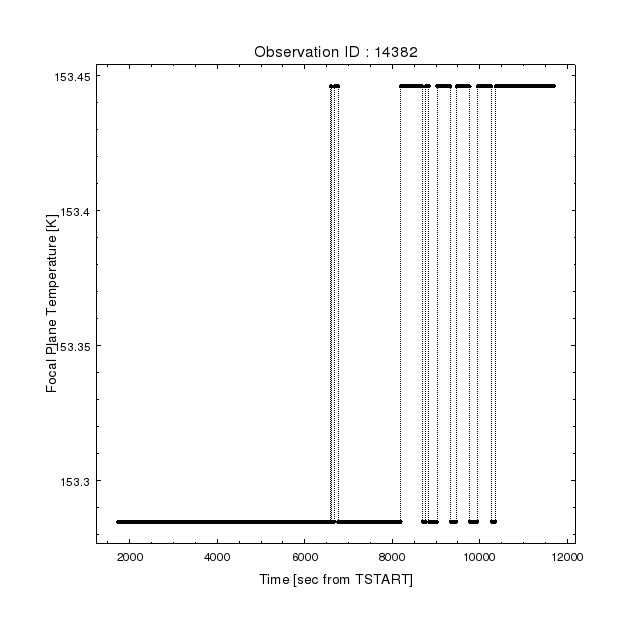

In [17]:
 dmtabfilt in=fptemp.fits out=- col=fp_temp function=extreme mask="111" | \
  dmtabfilt in=- out=- col=fp_temp_extreme function=median mask=")101" | \
  dmpaste fptemp.fits - fp_temp_extreme_median clob+ 

PlotFile fp_temp_extreme_median"[cols time,fp_temp_extreme_median]" chips_12.png